***Employee Turnover Analytics***

Description

Project Statement:

Portobello Tech is an app innovator who has devised an intelligent way of predicting employee turnover within the company. It periodically evaluates employees' work details, including the number of projects they worked on, average monthly working hours, time spent in the company, promotions in the last five years, and salary level.

Data from prior evaluations shows the employees’ satisfaction in the workplace. The data could be used to identify patterns in work style and their interest in continuing to work for the company.

The HR Department owns the data and uses it to predict employee turnover. Employee turnover refers to the total number of workers who leave a company over time.

As the ML Developer assigned to the HR Department, you have been asked to create ML programs to:

1.    Perform data quality checks by checking for missing values, if any.
2.    Understand what factors contributed most to employee turnover at EDA.
3.    Perform clustering of employees who left based on their satisfaction and evaluation.
4.    Handle the left Class Imbalance using the SMOTE technique.
5.    Perform k-fold cross-validation model training and evaluate performance.
6.    Identify the best model and justify the evaluation metrics used.
7.    Suggest various retention strategies for targeted employees.



In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [48]:
data=pd.read_csv('HR_comma_sep.csv')

In [49]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [50]:
data.tail()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low
14998,0.37,0.52,2,158,3,0,1,0,support,low


In [51]:
print(data.shape)

(14999, 10)


In [52]:
# Checking for unique values in Sales Column
data['sales'].value_counts()

,count
sales,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


In [53]:
# Checking for unique values in Salary Column
data['salary'].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


In [54]:
# # Checking for unique values in left(label) Column
data['left'].value_counts()

,count
left,
0,11428
1,3571


2. **Data cleaning**

Cleaning Data of missing values, duplicates and Outliers

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


Data has no missing values

In [56]:
# Checking Statistical mean of the dataset
data.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [57]:
# Remove duplicates and keep the first occurrence
data = data.drop_duplicates(keep='first')

In [58]:
# Verify that duplicates have been removed
print(data.duplicated().sum())  # Output should be 0

0


Machine learning models typically work best with numerical data. Since the 'sales' and 'salary' columns are  categorical, we need to convert them into a numerical format that the models can understand. One-hot encoding is a common technique for this.

In [59]:
# One-hot encoding using pandas get_dummies
# drop_first=True: This argument drops the first category for each column to avoid multicollinearity issues (redundancy in the data).
data = pd.get_dummies(data, columns=['sales', 'salary'], drop_first=True)

In [60]:
# Display the modified DataFrame
display(data.head())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


**EXploratory Data Analysis**

To understand what factors contributed most to employee turnover, we will perform EDA of various features with label.

In [65]:
# Correlation Analysis
correlation_matrix=data.corr()

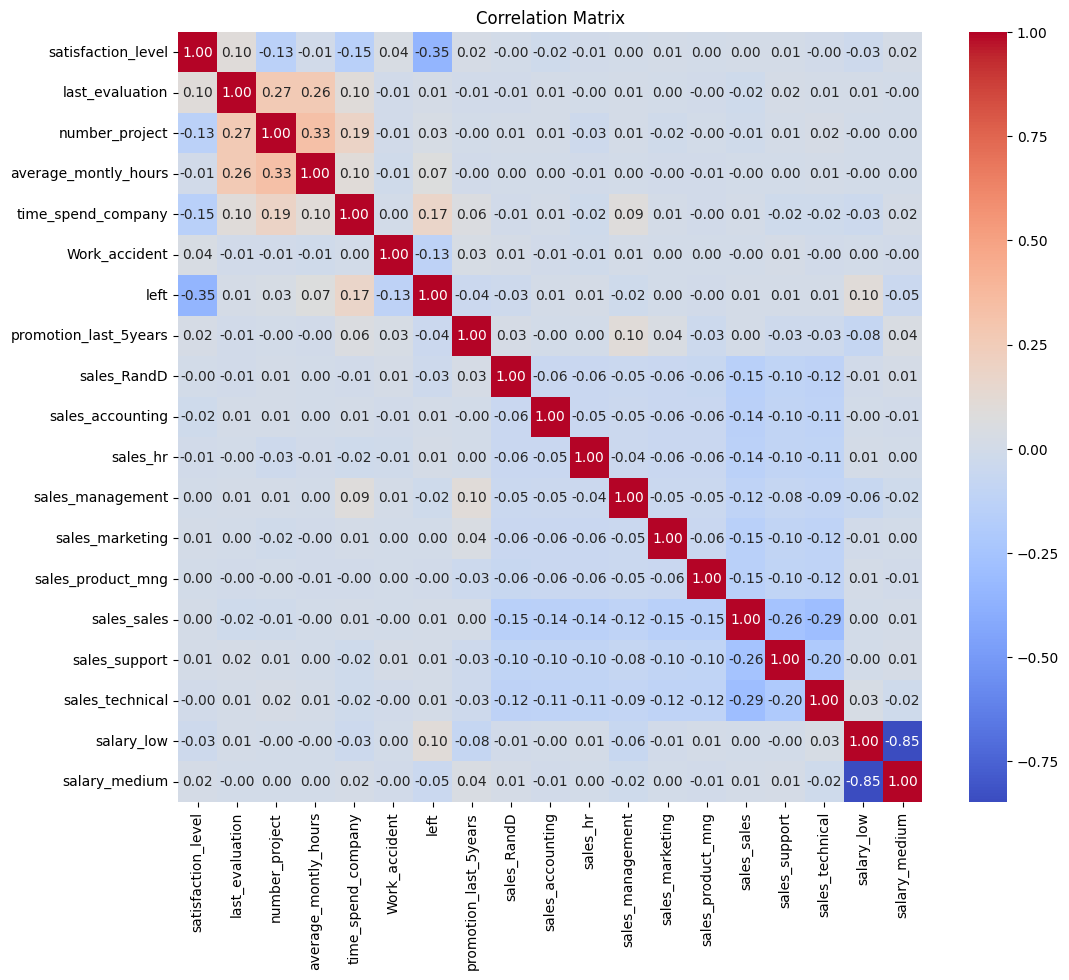

In [66]:
plt.figure(figsize=(12, 10))  # Adjust width and height as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


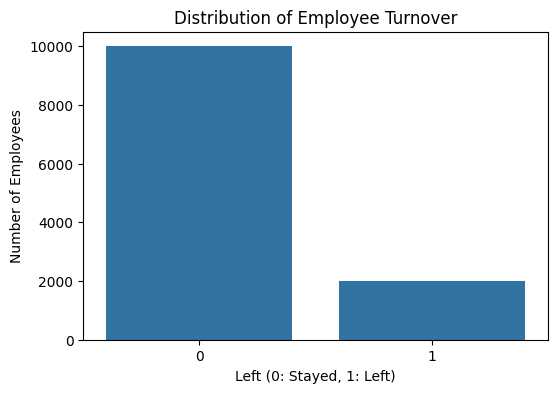

In [67]:
# Analyze the distribution of the 'left' column
plt.figure(figsize=(6, 4))
sns.countplot(x='left', data=data)
plt.title('Distribution of Employee Turnover')
plt.xlabel('Left (0: Stayed, 1: Left)')
plt.ylabel('Number of Employees')
plt.show()

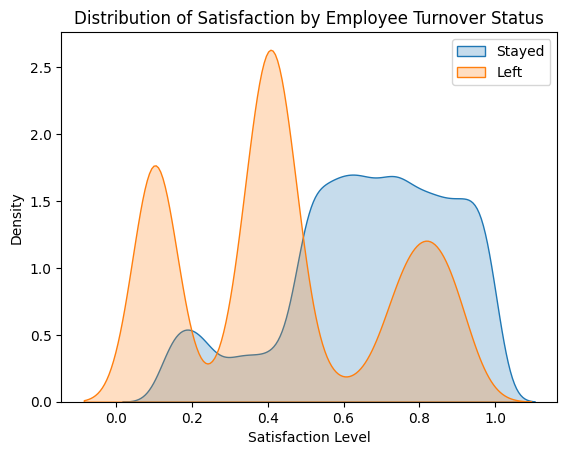

In [68]:
# Relationship between satisfaction level and employee turnover.

sns.kdeplot(df[df['left'] == 0]['satisfaction_level'], label='Stayed', shade=True)
sns.kdeplot(df[df['left'] == 1]['satisfaction_level'], label='Left', shade=True)
plt.title('Distribution of Satisfaction by Employee Turnover Status')
plt.xlabel('Satisfaction Level')
plt.ylabel('Density')
plt.legend()
plt.show()



The  plot shows lower satisfaction is associated with higher turnover.

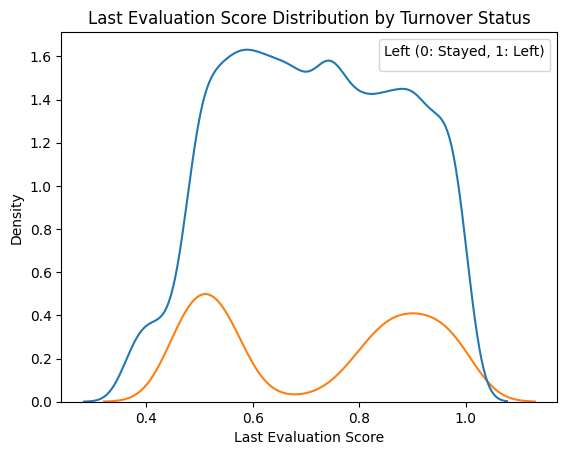

In [69]:
sns.kdeplot(data=df, x='last_evaluation', hue='left')
plt.title('Last Evaluation Score Distribution by Turnover Status')
plt.xlabel('Last Evaluation Score')
plt.ylabel('Density')
plt.legend(title='Left (0: Stayed, 1: Left)')  # Set legend title
plt.show()

Key Insights:
Employees who stayed (blue):

Have a wide spread of evaluation scores.

Most common scores are between 0.6 and 0.9.

This group shows multiple peaks — suggesting multiple clusters of performance among those who stayed.

Employees who left (orange):

Have two distinct peaks:

One peak at a low evaluation score (~0.45).

Another peak at a very high score (~0.85–0.9).

This suggests bimodal turnover: both underperformers and top performers are more likely to leave.

Low performers may be leaving due to poor performance, possibly being let go.

High performers may be leaving due to lack of growth, recognition, or opportunities, which is a concern for talent retention.

Middle scorers (0.6–0.8) are more likely to stay — perhaps they are consistent, stable employees not at risk of leaving or being let go.

In [70]:
data.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales_RandD', 'sales_accounting', 'sales_hr',
       'sales_management', 'sales_marketing', 'sales_product_mng',
       'sales_sales', 'sales_support', 'sales_technical', 'salary_low',
       'salary_medium'],
      dtype='object')

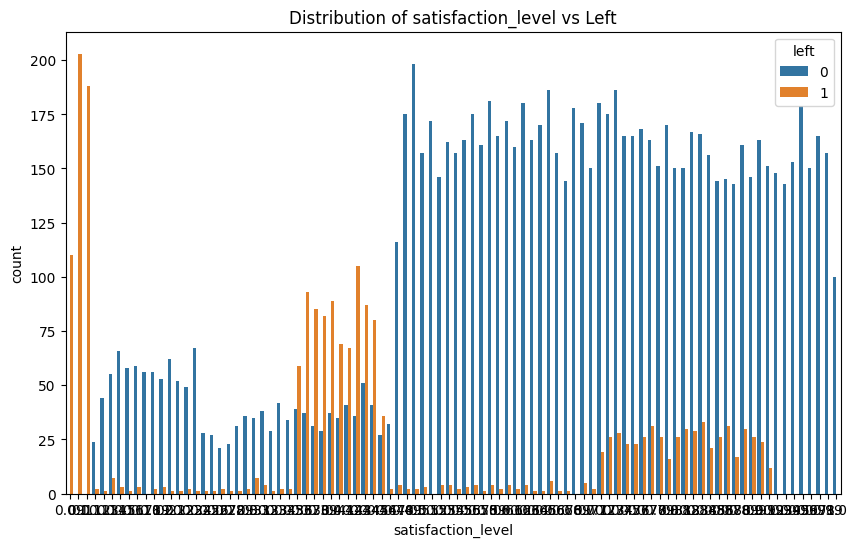

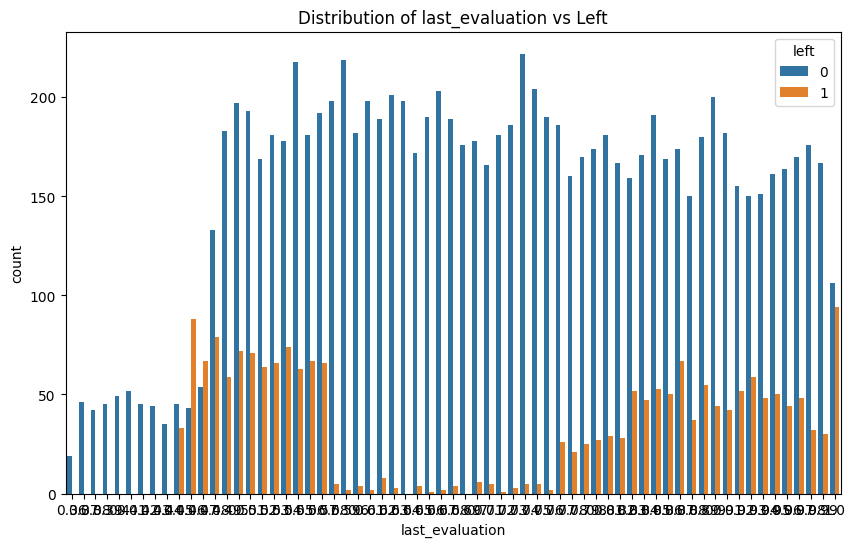

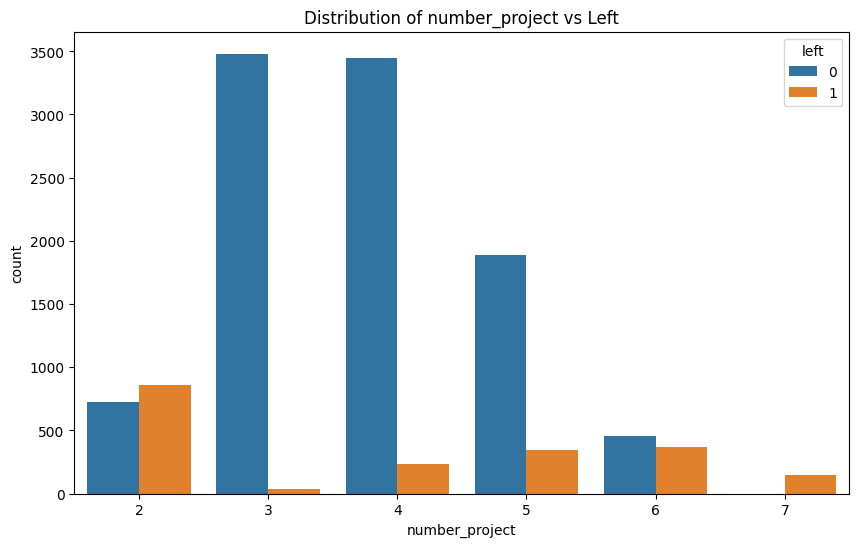

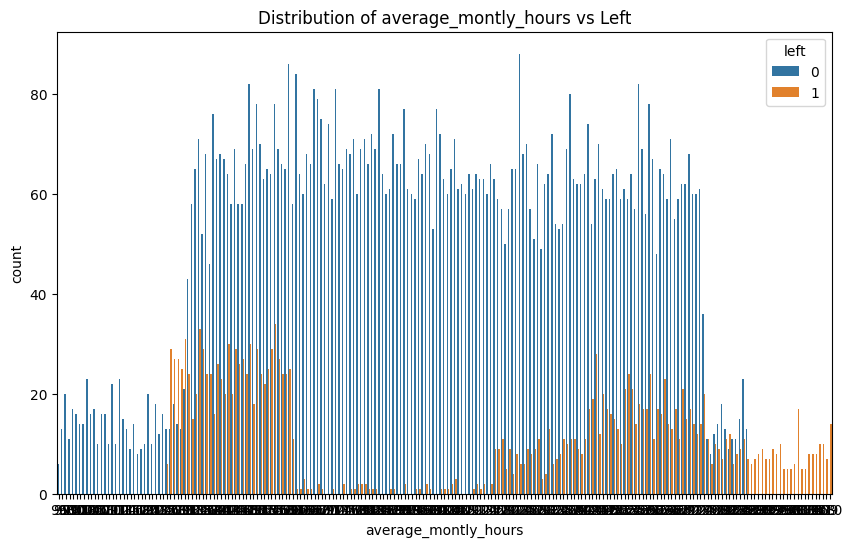

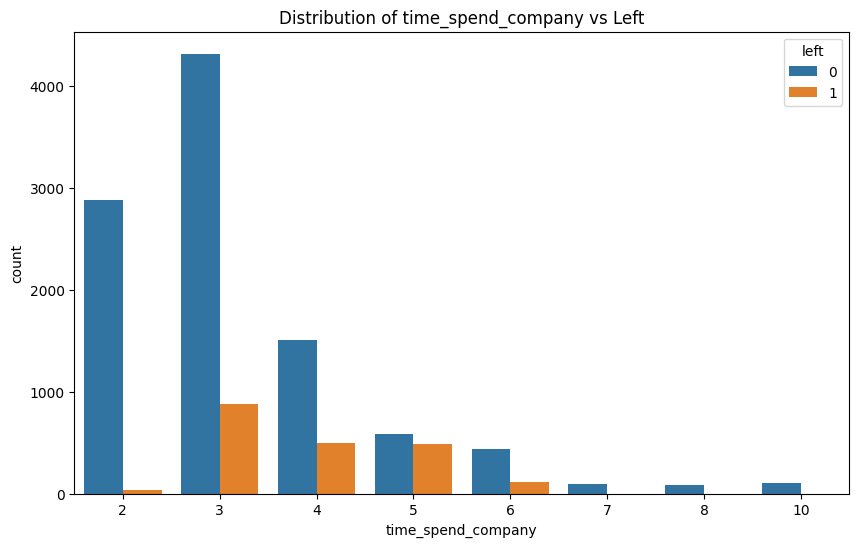

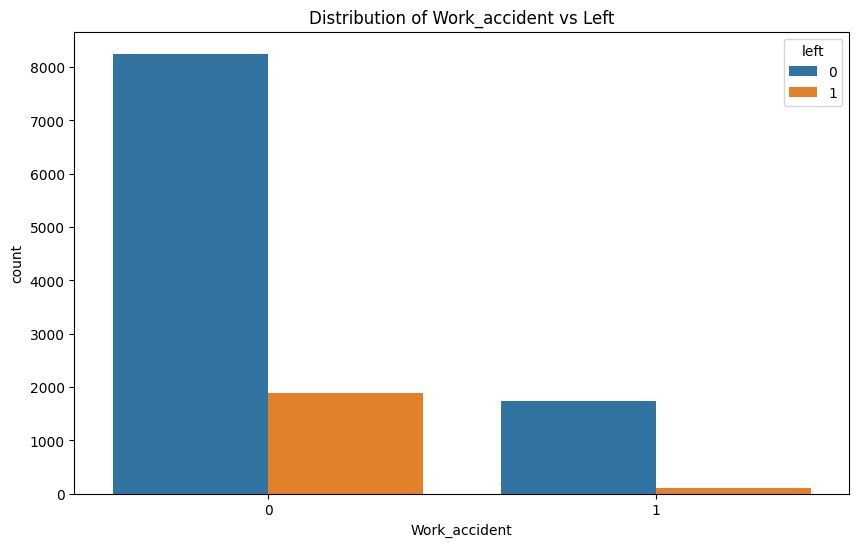

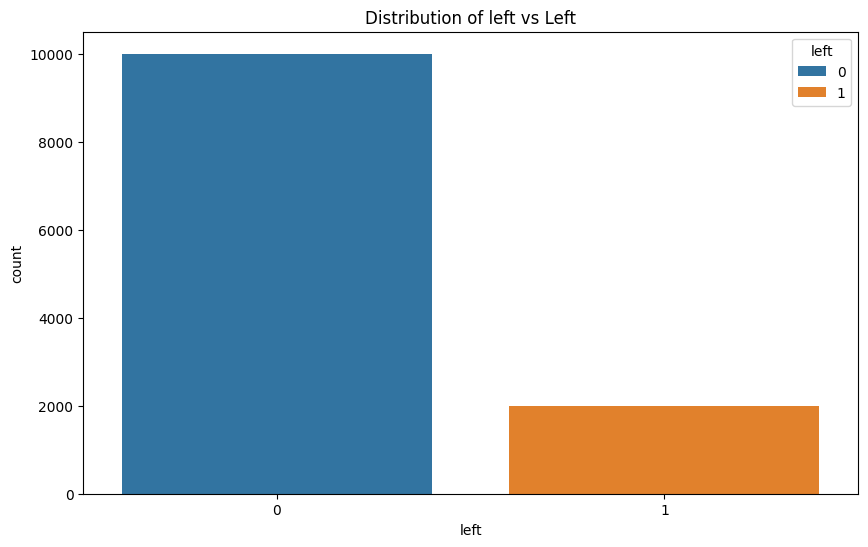

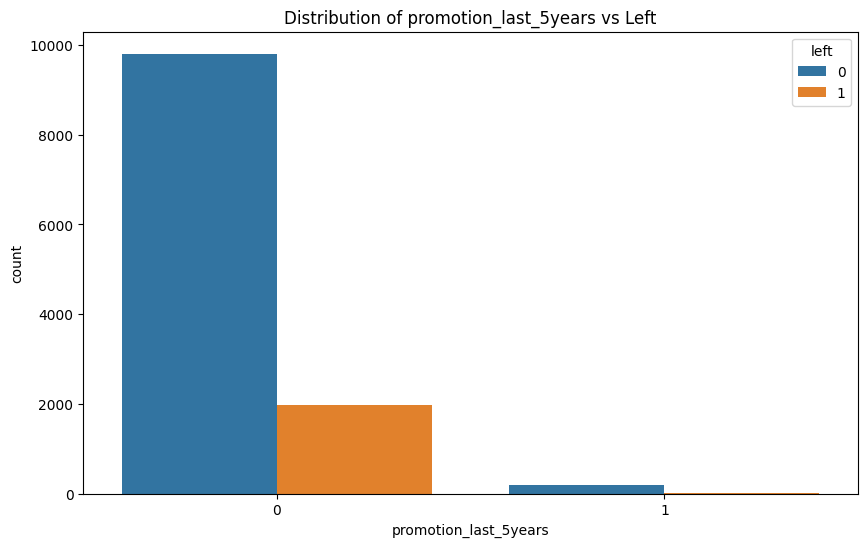

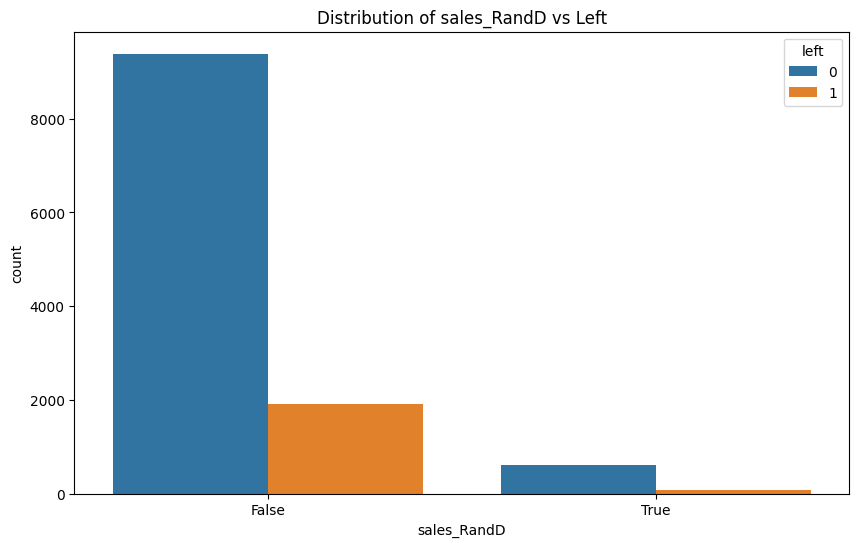

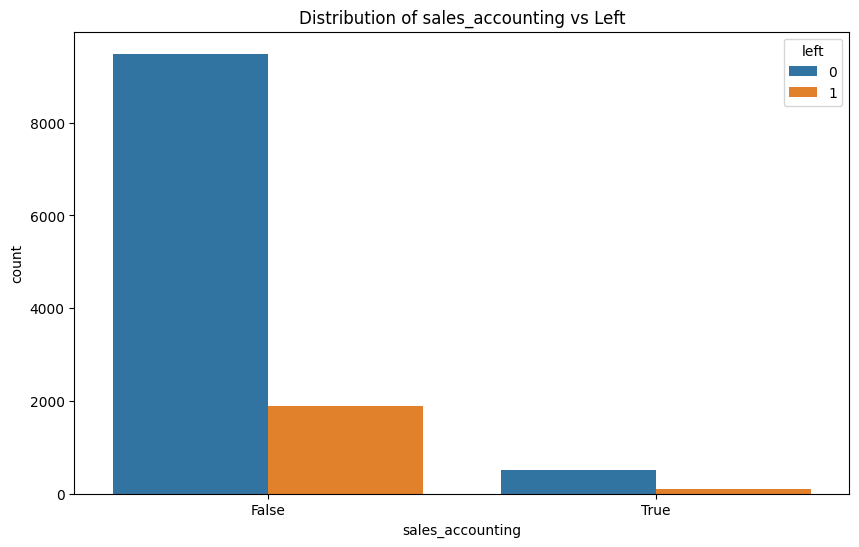

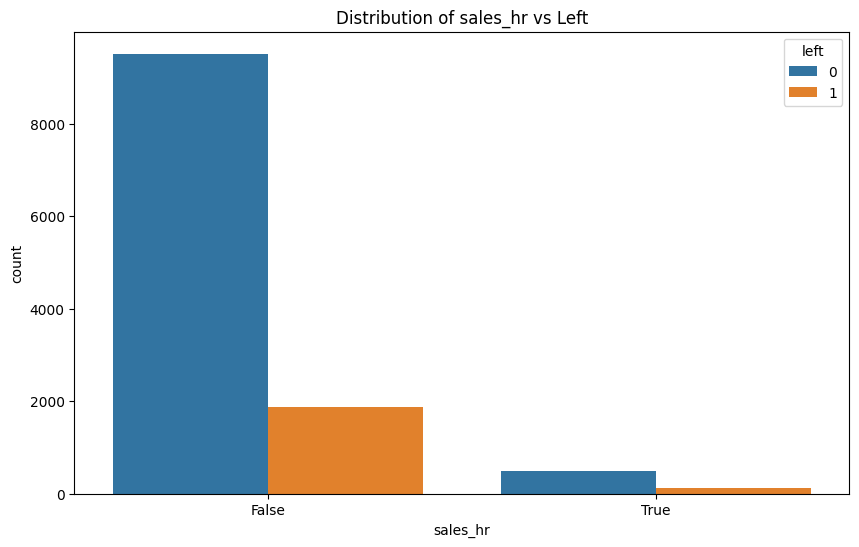

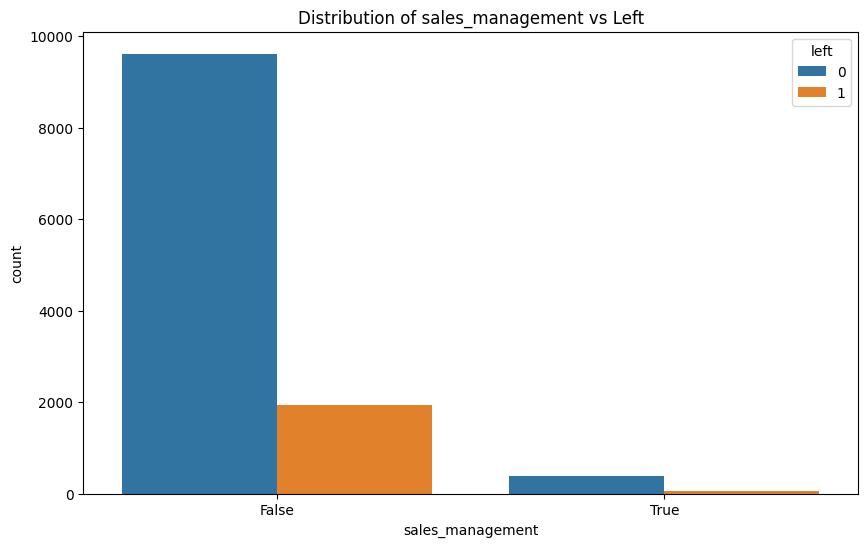

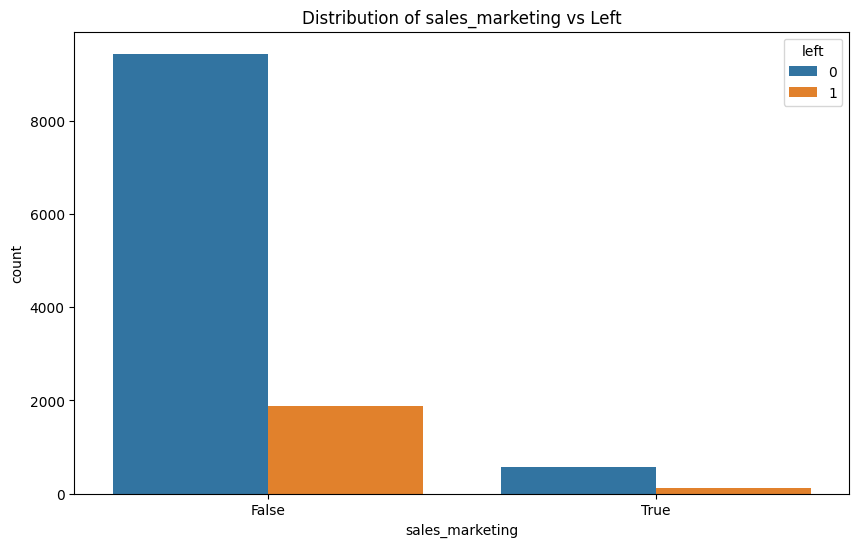

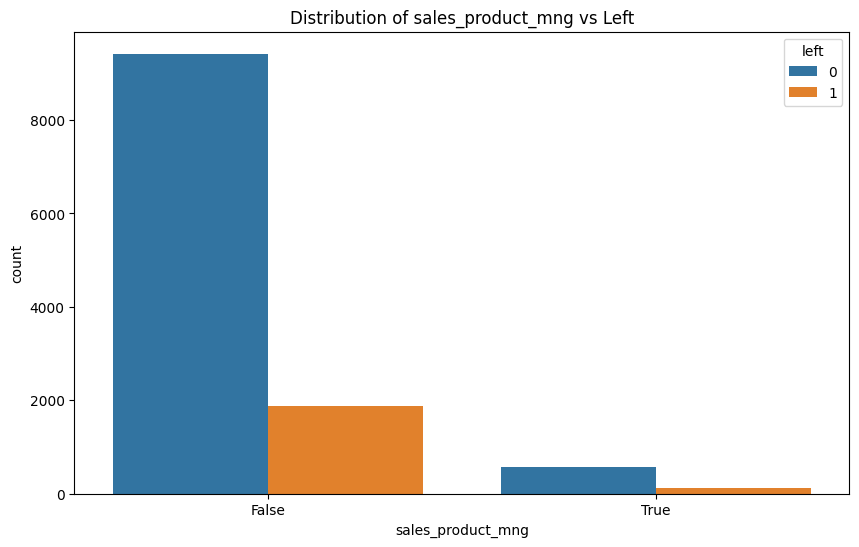

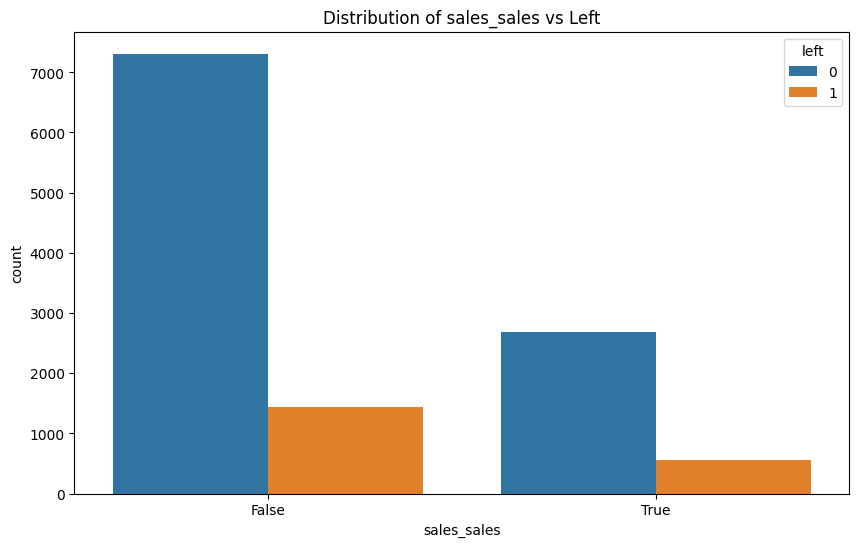

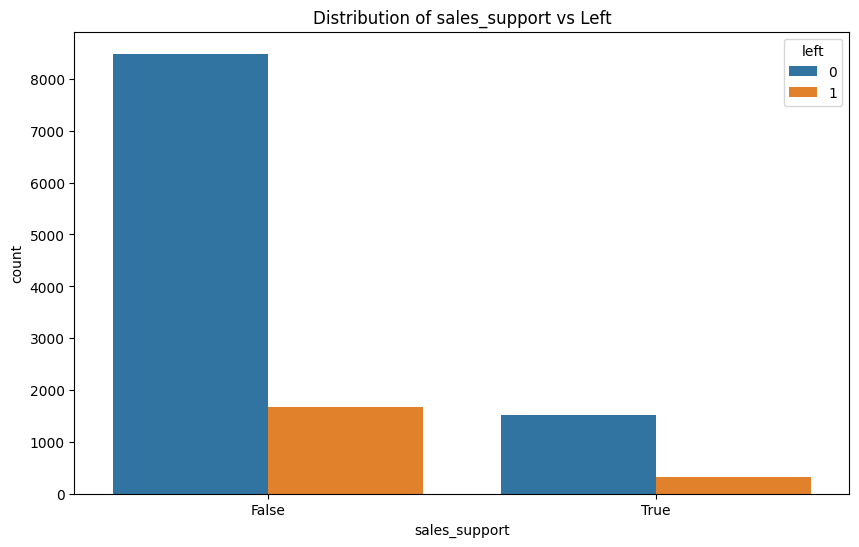

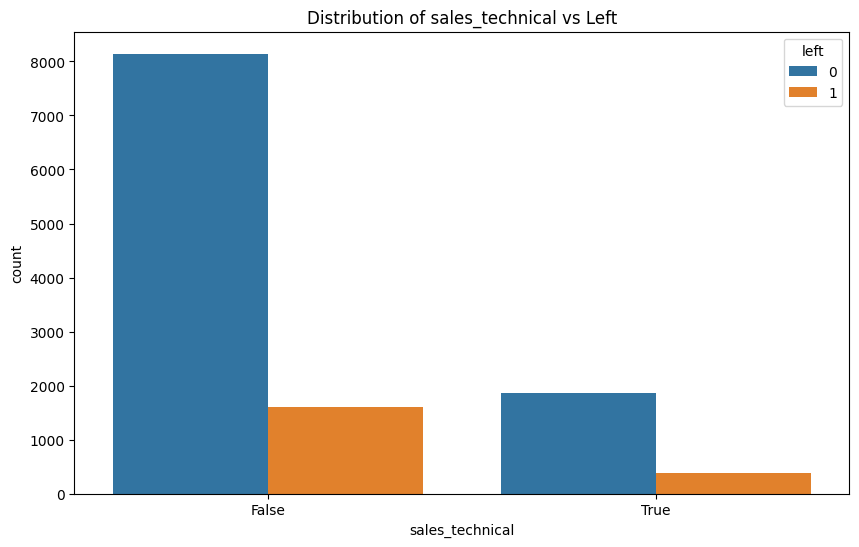

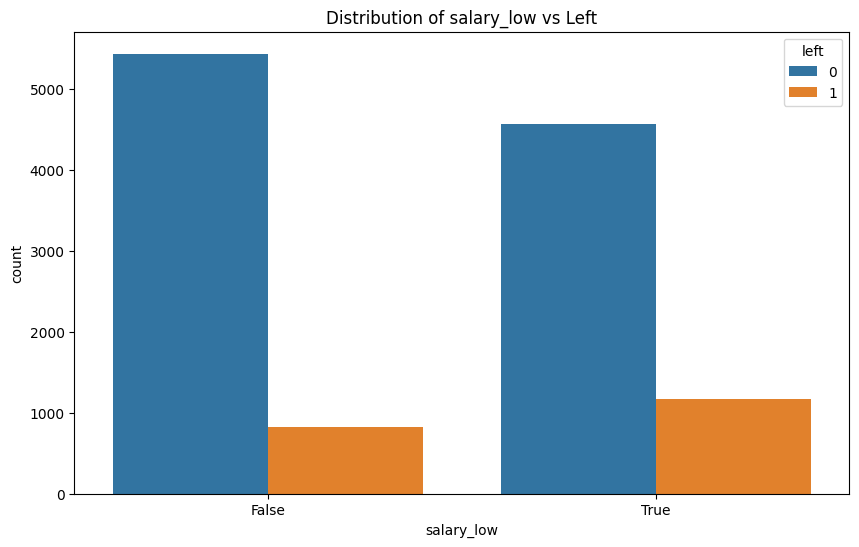

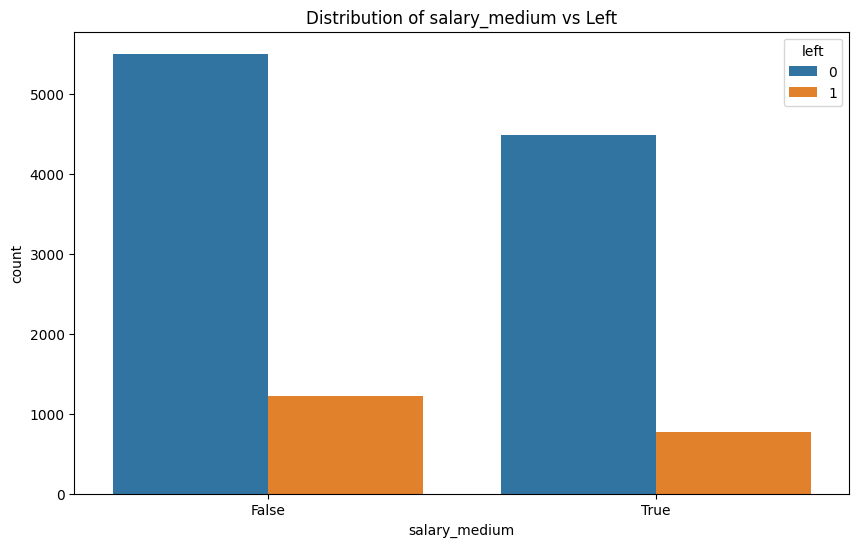

In [71]:
cols = ['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales_RandD', 'sales_accounting', 'sales_hr',
       'sales_management', 'sales_marketing', 'sales_product_mng',
       'sales_sales', 'sales_support', 'sales_technical', 'salary_low',
       'salary_medium']
for col in cols:
    plt.figure(figsize=(10,6))
    sns.countplot(x=col, hue='left', data=data)
    plt.title(f'Distribution of {col} vs Left')
    plt.show()

**Observations from EDA:**

Low satisfaction, low salary, no promotion, and high/low project load = higher attrition

Certain departments like sales/support may have higher turnover

Work accidents and promotions appear to reduce attrition

These visualizations help HR target retention strategies more precisely.

**Clustering**

I will perform cluster analysis based on Satisfaction and evalvation

In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   sales_RandD            11991 non-null  bool   
 9   sales_accounting       11991 non-null  bool   
 10  sales_hr               11991 non-null  bool   
 11  sales_management       11991 non-null  bool   
 12  sales_marketing        11991 non-null  bool   
 13  sales_product_mng      11991 non-null  bool   
 14  sales_sales            11991 non-null  bool   
 15  sales_s

In [74]:
features = data.iloc[:,[0,1]].values

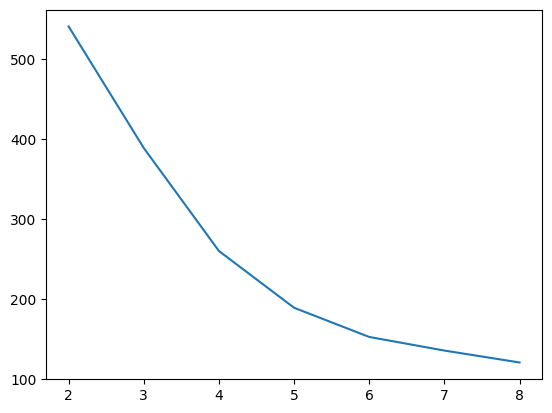

In [75]:
# 1. Identify how many number of hidden categories are present.

# Get WCSS (WithIn Cluster Sum of Square) -- Error Metric

# THE ELBOW METHOD
from sklearn.cluster import KMeans

wcss = []

for category in range(2,9):
  model = KMeans(n_clusters=category)
  model.fit(features)
  wcss.append(model.inertia_)

plt.plot(range(2,9) , wcss)

From the Elbow curve , we get no of clusters as 5.

In [76]:
#Model Building

finalModel = KMeans(n_clusters=5)
finalModel.fit(features)

KMeans(n_clusters=5)

In [77]:
# Predict Labels/Groups

labelData = finalModel.predict(features)
labelData

array([2, 4, 3, ..., 1, 2, 0], dtype=int32)

In [78]:
finalDataset = data.iloc[:,[0,1]]
finalDataset['category'] = labelData
finalDataset

,satisfaction_level,last_evaluation,category
0,0.38,0.53,2
1,0.80,0.86,4
2,0.11,0.88,3
3,0.72,0.87,4
4,0.37,0.52,2
...,...,...,...
11995,0.90,0.55,1
11996,0.74,0.95,4
11997,0.85,0.54,1
11998,0.33,0.65,2


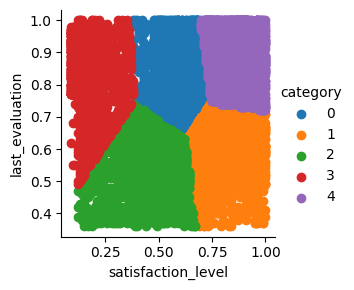

In [79]:
import seaborn as sns
sns.FacetGrid(finalDataset, hue='category').map(plt.scatter,'satisfaction_level',	'last_evaluation').add_legend()

**SMOTE Technique**

Handle class imbalance

In [80]:
data['left'].value_counts()

,count
left,
0,10000
1,1991


Our dataset is highly imbalanced, so we will balance the classes using SMOTE.

In [81]:
from imblearn.over_sampling import SMOTE

In [82]:
#Seperate data as features and label

features = data.drop(columns=['left'])
label = data['left']


In [83]:
#Initialize smote and fit data
smote = SMOTE(random_state=1)
resampledFeatures, resampledLabel = smote.fit_resample(features,label)

In [84]:
resampledDF = pd.concat([pd.DataFrame(resampledFeatures, columns=features.columns) , pd.DataFrame(resampledLabel, columns=['left'])])
resampledDF.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     20000 non-null  float64
 1   last_evaluation        20000 non-null  float64
 2   number_project         20000 non-null  float64
 3   average_montly_hours   20000 non-null  float64
 4   time_spend_company     20000 non-null  float64
 5   Work_accident          20000 non-null  float64
 6   promotion_last_5years  20000 non-null  float64
 7   sales_RandD            20000 non-null  object 
 8   sales_accounting       20000 non-null  object 
 9   sales_hr               20000 non-null  object 
 10  sales_management       20000 non-null  object 
 11  sales_marketing        20000 non-null  object 
 12  sales_product_mng      20000 non-null  object 
 13  sales_sales            20000 non-null  object 
 14  sales_support          20000 non-null  object 
 15  sales_t

In [85]:
resampledDF['left'].value_counts()

,count
left,
1.0,10000
0.0,10000


Classes are now balanced using SMOTE

 **k-fold cross-validation**


In [86]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from xgboost import XGBRFClassifier  # For XGBRF classifier
import pandas as pd

results = []
models = [
    {'model_name': 'LogisticRegression', 'instance': LogisticRegression()},
    {'model_name': 'KNeighborsClassifier', 'instance': KNeighborsClassifier()},
    {'model_name': 'DecisionTreeClassifier', 'instance': DecisionTreeClassifier()},
    {'model_name': 'SVC', 'instance': SVC()},
    {'model_name': 'Bagging(LogisticRegression)', 'instance': BaggingClassifier(LogisticRegression())},
    {'model_name': 'Bagging(KNeighborsClassifier)', 'instance': BaggingClassifier(KNeighborsClassifier())},
    {'model_name': 'RandomForestClassifier', 'instance': RandomForestClassifier()},
    {'model_name': 'XGBClassifier', 'instance': XGBClassifier()},
    {'model_name': 'XGBRFClassifier', 'instance': XGBRFClassifier()}  # Added XGBRF
]

cvs = [5, 10]  # Assuming you have defined 'cvs'

for model in models:
    for cvs_number in cvs:
        scores = cross_val_score(model['instance'], features, label, cv=cvs_number)
        model_name = model['model_name']
        cvs_str = f'cvs: {str(cvs_number)}'
        results.append({'Model': model_name, 'CVS': cvs_str, 'Scores': scores.mean()})

results_df = pd.DataFrame(results)
print(results_df)

best_model = results_df.groupby('Model')['Scores'].mean().idxmax()
best_cvs = results_df[results_df['Model'] == best_model]['CVS'].values[0]

print(f'the best model is: {best_model} with a cvs of: {best_cvs}')

                            Model      CVS    Scores
0              LogisticRegression   cvs: 5  0.815443
1              LogisticRegression  cvs: 10  0.819196
2            KNeighborsClassifier   cvs: 5  0.943290
3            KNeighborsClassifier  cvs: 10  0.942874
4          DecisionTreeClassifier   cvs: 5  0.967726
5          DecisionTreeClassifier  cvs: 10  0.966892
6                             SVC   cvs: 5  0.833959
7                             SVC  cvs: 10  0.833959
8     Bagging(LogisticRegression)   cvs: 5  0.818445
9     Bagging(LogisticRegression)  cvs: 10  0.818529
10  Bagging(KNeighborsClassifier)   cvs: 5  0.942206
11  Bagging(KNeighborsClassifier)  cvs: 10  0.943541
12         RandomForestClassifier   cvs: 5  0.982987
13         RandomForestClassifier  cvs: 10  0.983654
14                  XGBClassifier   cvs: 5  0.981402
15                  XGBClassifier  cvs: 10  0.982070
16                XGBRFClassifier   cvs: 5  0.979651
17                XGBRFClassifier  cvs: 10  0.

**Data Modelling**

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [88]:
# Assuming you have your features (X) and target (y) prepared
X = df.drop('left', axis=1)  # Replace 'df' with your DataFrame
y = df['left']


In [89]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Initial random state



In [94]:
for rs in range(1,50):
  X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size=0.2,
                                                 random_state=rs)

  model = RandomForestClassifier()
  model.fit(X_train,y_train)

  testScore = model.score(X_test,y_test)
  trainScore = model.score(X_train,y_train)

  #if testScore > trainScore and testScore >= CL:
  print(f"Test Score {testScore} | TrainScore {trainScore} | Rs {rs}")

Test Score 0.9817642069550466 | TrainScore 1.0 | Rs 1
Test Score 0.9800678541136556 | TrainScore 0.9998939554612938 | Rs 2
Test Score 0.9855810008481765 | TrainScore 0.9998939554612938 | Rs 3
Test Score 0.9864291772688719 | TrainScore 1.0 | Rs 4
Test Score 0.9804919423240034 | TrainScore 0.9998939554612938 | Rs 5
Test Score 0.9800678541136556 | TrainScore 1.0 | Rs 6
Test Score 0.9834605597964376 | TrainScore 1.0 | Rs 7
Test Score 0.9821882951653944 | TrainScore 1.0 | Rs 8
Test Score 0.9838846480067854 | TrainScore 1.0 | Rs 9
Test Score 0.9817642069550466 | TrainScore 1.0 | Rs 10
Test Score 0.9800678541136556 | TrainScore 1.0 | Rs 11
Test Score 0.9843087362171332 | TrainScore 1.0 | Rs 12
Test Score 0.9779474130619169 | TrainScore 1.0 | Rs 13
Test Score 0.9843087362171332 | TrainScore 1.0 | Rs 14
Test Score 0.9826123833757422 | TrainScore 1.0 | Rs 15
Test Score 0.9775233248515691 | TrainScore 1.0 | Rs 16
Test Score 0.9826123833757422 | TrainScore 1.0 | Rs 17
Test Score 0.9843087362171332

In [95]:
rfc = RandomForestClassifier(n_estimators=50,random_state=25)
rfc.fit(X_train,y_train)


RandomForestClassifier(n_estimators=50, random_state=25)

In [104]:
# Get feature importances
importances = rfc.feature_importances_

In [105]:
# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values('Importance', ascending=False)

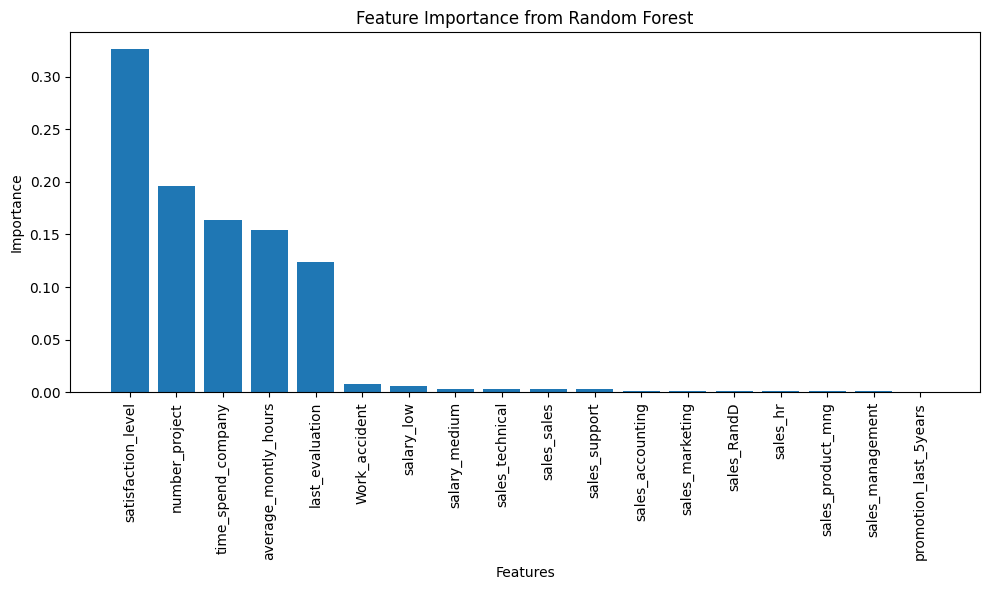

In [106]:
# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(feature_importances['Feature'], feature_importances['Importance'])
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

The Feature Importance from Random Forest provides powerful insights into which factors are most influential in predicting employee turnover.

**Top 5 Most Important Features:**

**1. Satisfaction Level**
Most critical feature.

Employees with low satisfaction are much more likely to leave.

Strong indicator of emotional engagement and workplace happiness.

Action: Regularly monitor and improve employee satisfaction.

**2. Number of Projects**
Indicates workload or task diversity.

Very high or very low number of projects might indicate disengagement or burnout.

Action: Balance project allocation to avoid overload or boredom.

**3. Time Spent in Company**
Indicates tenure.

Employees who stay for a medium duration (e.g., 3–5 years) may be at a higher risk of leaving if growth slows down.

Action: Offer growth paths, especially after key milestones (3 years, 5 years, etc.).

**4. Average Monthly Hours**
Reflects workload.

Employees working extremely long hours may burn out and quit.

Action: Optimize work-life balance and prevent overworking.

**5. Last Evaluation**
Measures performance review scores.

Interestingly, employees with very low or very high evaluations may be at risk:

Low → Poor performance, dissatisfaction.

High → May feel undervalued or overworked.

Action: Provide clear feedback and career progression plans.


**Least Important Features:**

Promotion in Last 5 Years, Salary Levels, Department:

Surprisingly, these had very low importance in the Random Forest model.

Could be due to:

Imbalanced promotion data (few promotions overall),

Salary encoded poorly (e.g., categorical instead of ordinal),

Department not strongly correlated with turnover in this dataset.

**Predictions and Evaluation**

In [96]:
predictions = rfc.predict(X_test)

In [97]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1942
           1       0.98      0.91      0.94       416

    accuracy                           0.98      2358
   macro avg       0.98      0.95      0.96      2358
weighted avg       0.98      0.98      0.98      2358



In [98]:
print(confusion_matrix(y_test,predictions))

[[1933    9]
 [  38  378]]


In [100]:
# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(accuracy)


0.9800678541136556


**Retention Strategies**

**1.For Low Satisfaction:**

Employee engagement programs

Better work-life balance

**2.For Overworked High Performers:**

Offer growth opportunities, recognition, or compensation bumps.

**3.Salary Adjustment Strategy:**
Mid and low salary band employees more prone to leave → Consider reviewing salary structure or offer benefits.

**4.Proactive Promotion Planning:**
High-performing long-tenure employees with no promotions → At risk. Implement internal mobility plans.

